<a href="https://colab.research.google.com/github/AtharvBheda/AtharvBheda/blob/main/DrowsinessDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installing Packages

In [ ]:
!pip install tensorflow
!pip install opencv-python

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import imghdr
import tensorflow as tf
from PIL import Image
import seaborn as sns
from collections import Counter
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import shutil
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import layers, models, regularizers, optimizers
from tensorflow.keras.applications import VGG16, ResNet50V2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard, CSVLogger
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense, Activation, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from keras.utils import plot_model

<ipython-input-3-80af5f9ee689>:7: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory


##Download and unzip Dataset from Kaggle

In [ ]:
# Section 3: Download Dataset
# ==========================
def download_dataset():
    # Create a directory for the dataset
    dataset_dir = "/content/dataset"
    os.makedirs(dataset_dir, exist_ok=True)

    # Only download if not already present
    if not os.path.exists("/content/dataset/drowsy") and not os.path.exists("/content/dataset/nondrowsy"):
        print("Downloading dataset from Kaggle...")
        !kaggle datasets download -d atharvbheda/employee-drowsiness-detection

        print("Extracting dataset...")
        !unzip -q /content/employee-drowsiness-detection.zip -d /content/
        print("Dataset downloaded and extracted")
    else:
        print("Dataset already exists, skipping download")

    # Verify dataset structure
    if os.path.exists("/content/dataset"):
        drowsy_dir = "/content/dataset/drowsy"
        nondrowsy_dir = "/content/dataset/nondrowsy"

        if os.path.exists(drowsy_dir) and os.path.exists(nondrowsy_dir):
            drowsy_count = len(os.listdir(drowsy_dir))
            nondrowsy_count = len(os.listdir(nondrowsy_dir))
            print(f"Dataset contains {drowsy_count} drowsy images and {nondrowsy_count} non-drowsy images")
        else:
            print("Warning: Expected directory structure not found")

# Run dataset download
download_dataset()

Dataset URL: https://www.kaggle.com/datasets/atharvbheda/employee-drowsiness-detection
License(s): unknown
Extracting dataset...
Dataset downloaded and extracted
Dataset contains 6019 drowsy images and 6051 non-drowsy images


##Create Directory Structure

In [ ]:
def create_directory_structure(base_dir):
    # Create a parent directory for organized data
    os.makedirs(base_dir, exist_ok=True)

    class_names = ['drowsy', 'nondrowsy']
    splits = ['train', 'val', 'test']

    for split in splits:
        for cls in class_names:
            os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

    print(f"Created directory structure at {base_dir}")

# Define the base directory for the organized data
base_dir = '/content/Drowsiness_Detection_Demo/final_split'
create_directory_structure(base_dir)


Created directory structure at /content/Drowsiness_Detection_Demo/final_split


##Collect Files and Labels

In [ ]:
def collect_files(data_dir):
    file_paths = []
    labels = []
    class_counts = {}

    for class_name in ['drowsy', 'nondrowsy']:
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: Class directory {class_dir} not found")
            continue

        class_files = [os.path.join(class_dir, file) for file in os.listdir(class_dir)
                      if file.lower().endswith(('.png', '.jpg', '.jpeg'))]

        file_paths.extend(class_files)
        class_label = 1 if class_name == 'drowsy' else 0
        labels.extend([class_label] * len(class_files))
        class_counts[class_name] = len(class_files)

    print(f"Found {len(file_paths)} images")
    print(f"Class distribution: {class_counts}")

    return file_paths, labels

# Collect file paths and labels
original_data_dir = '/content/dataset'
file_paths, labels = collect_files(original_data_dir)

Found 12070 images
Class distribution: {'drowsy': 6019, 'nondrowsy': 6051}


##Split Data into Train, Validation, and Test Sets

In [ ]:
def split_data(file_paths, labels):
    # Split with stratification for class balance
    train_files, temp_files, train_labels, temp_labels = train_test_split(
        file_paths, labels,
        test_size=0.3,
        stratify=labels,
        random_state=42
    )

    val_files, test_files, val_labels, test_labels = train_test_split(
        temp_files, temp_labels,
        test_size=0.5,
        stratify=temp_labels,
        random_state=42
    )

    # Verify splits
    print("\nTrain-Val-Test Split:")
    print(f"Train: {len(train_files)} images - Class balance: {Counter(train_labels)}")
    print(f"Validation: {len(val_files)} images - Class balance: {Counter(val_labels)}")
    print(f"Test: {len(test_files)} images - Class balance: {Counter(test_labels)}")

    return train_files, val_files, test_files, train_labels, val_labels, test_labels

# Split the dataset
train_files, val_files, test_files, train_labels, val_labels, test_labels = split_data(file_paths, labels)



Train-Val-Test Split:
Train: 8449 images - Class balance: Counter({0: 4236, 1: 4213})
Validation: 1810 images - Class balance: Counter({0: 907, 1: 903})
Test: 1811 images - Class balance: Counter({0: 908, 1: 903})


##Copy Files to Train/Val/Test Directories

In [ ]:
def copy_files_with_validation(files, labels, split_folder, base_dir):
    error_count = 0
    success_count = 0

    for file_path, label in tqdm(zip(files, labels), desc=f"Copying {split_folder}", total=len(files)):
        # Skip missing files
        if not os.path.isfile(file_path):
            print(f"Missing file: {file_path}")
            error_count += 1
            continue

        # Simple image validation
        try:
            with Image.open(file_path) as img:
                # This verifies the file is a valid image
                img.verify()
        except Exception as e:
            print(f"Invalid image: {file_path} - {str(e)}")
            error_count += 1
            continue

        # Get class from label
        class_name = 'drowsy' if label == 1 else 'nondrowsy'
        dest_path = os.path.join(base_dir, split_folder, class_name, os.path.basename(file_path))
        shutil.copy2(file_path, dest_path)
        success_count += 1

    print(f"Copied {success_count} files to {split_folder}, {error_count} errors")
    return success_count, error_count

# Copy files to respective directories
# Note: This may take some time depending on the dataset size
copy_files_with_validation(train_files, train_labels, 'train', base_dir)
copy_files_with_validation(val_files, val_labels, 'val', base_dir)
copy_files_with_validation(test_files, test_labels, 'test', base_dir)


Copying train: 100%|██████████| 8449/8449 [00:11<00:00, 719.58it/s]


Copied 8449 files to train, 0 errors


Copying val: 100%|██████████| 1810/1810 [00:04<00:00, 426.25it/s]


Copied 1810 files to val, 0 errors


Copying test: 100%|██████████| 1811/1811 [00:04<00:00, 364.04it/s]

Copied 1811 files to test, 0 errors


(1811, 0)

##Verify Dataset Splits

In [ ]:
def verify_splits(base_dir):
    result = {}
    for split in ['train', 'val', 'test']:
        split_result = {}
        for cls in ['drowsy', 'nondrowsy']:
            path = os.path.join(base_dir, split, cls)
            if os.path.exists(path):
                count = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
                split_result[cls] = count
        result[split] = split_result

    print("\nFinal Distribution:")
    for split, classes in result.items():
        total = sum(classes.values())
        print(f"{split}: {total} images - {classes}")

    return result

# Verify the splits
verify_splits(base_dir)


Final Distribution:
train: 8449 images - {'drowsy': 4213, 'nondrowsy': 4236}
val: 1810 images - {'drowsy': 903, 'nondrowsy': 907}
test: 1811 images - {'drowsy': 903, 'nondrowsy': 908}


{'train': {'drowsy': 4213, 'nondrowsy': 4236},
 'val': {'drowsy': 903, 'nondrowsy': 907},
 'test': {'drowsy': 903, 'nondrowsy': 908}}

##Build an Efficient tf.data Pipeline

##Data Augmentation

In [ ]:
def create_augmentation_model():
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal", input_shape=(224, 224, 3)),
        tf.keras.layers.RandomRotation(0.03),
        tf.keras.layers.RandomZoom(0.1, fill_mode='constant', fill_value=0),
        tf.keras.layers.RandomContrast(0.1)
    ])

# Create the augmentation model
data_augmentation = create_augmentation_model()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


##Image Processing Function

In [ ]:
def process_path(file_path):
    # Parse class from path
    parts = tf.strings.split(file_path, os.path.sep)
    class_name = parts[-2]  # Second-to-last element is class folder

    # Convert to numerical label (1=drowsy, 0=nondrowsy)
    label = tf.cast(tf.equal(class_name, "drowsy"), tf.int32)

    # Read and process image
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224))

    return img, label


##Build TensorFlow Datasets

In [ ]:
def build_tf_datasets(base_dir, batch_size=64):
    AUTOTUNE = tf.data.AUTOTUNE

    # Define directory paths
    train_dir = os.path.join(base_dir, 'train')
    val_dir = os.path.join(base_dir, 'val')
    test_dir = os.path.join(base_dir, 'test')

    # Create a function to get file paths and labels directly
    def get_dataset_from_directory(directory, shuffle=False, augment=False):
        return tf.keras.utils.image_dataset_from_directory(
            directory,
            labels='inferred',
            label_mode='binary',  # Binary classification
            class_names=['nondrowsy', 'drowsy'],  # Ensure order matches your label encoding
            image_size=(224, 224),
            batch_size=batch_size,
            shuffle=shuffle
        )

    # Build datasets using the simplified approach
    train_ds = get_dataset_from_directory(train_dir, shuffle=True)
    val_ds = get_dataset_from_directory(val_dir)
    test_ds = get_dataset_from_directory(test_dir)

    # Configure datasets for performance
    train_ds = train_ds.cache().prefetch(AUTOTUNE)
    val_ds = val_ds.cache().prefetch(AUTOTUNE)
    test_ds = test_ds.cache().prefetch(AUTOTUNE)

    # Apply preprocessing
    normalization_layer = tf.keras.layers.Rescaling(1./127.5, offset=-1)  # For ResNet preprocessing

    # Apply augmentation to training data
    data_augmentation = create_augmentation_model()

    train_ds = train_ds.map(
        lambda x, y: (normalization_layer(data_augmentation(x, training=True)), y),
        num_parallel_calls=AUTOTUNE
    )

    val_ds = val_ds.map(
        lambda x, y: (normalization_layer(x), y),
        num_parallel_calls=AUTOTUNE
    )

    test_ds = test_ds.map(
        lambda x, y: (normalization_layer(x), y),
        num_parallel_calls=AUTOTUNE
    )

    print(f"Created TensorFlow datasets with batch size {batch_size}")

    return train_ds, val_ds, test_ds

# Build the datasets
batch_size = 64  # You can adjust this based on your GPU memory
train_ds, val_ds, test_ds = build_tf_datasets(base_dir, batch_size)

Found 8449 files belonging to 2 classes.
Found 1810 files belonging to 2 classes.
Found 1811 files belonging to 2 classes.
Created TensorFlow datasets with batch size 64


##Visualize Dataset Samples

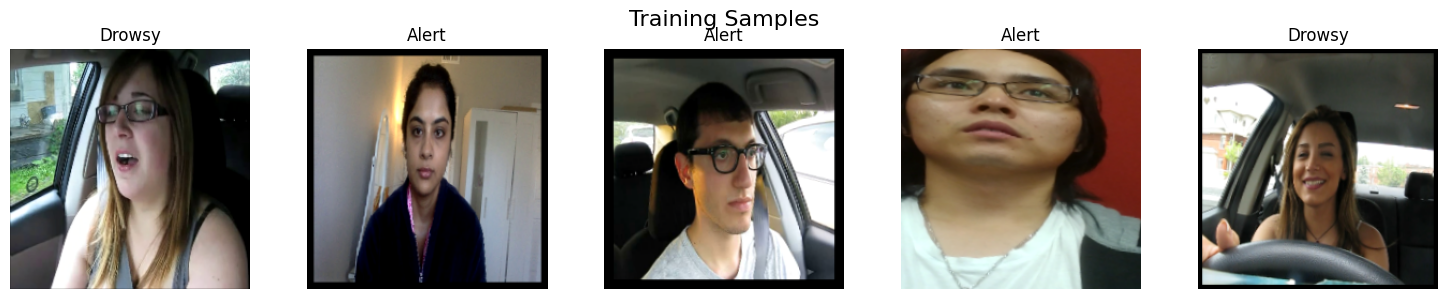

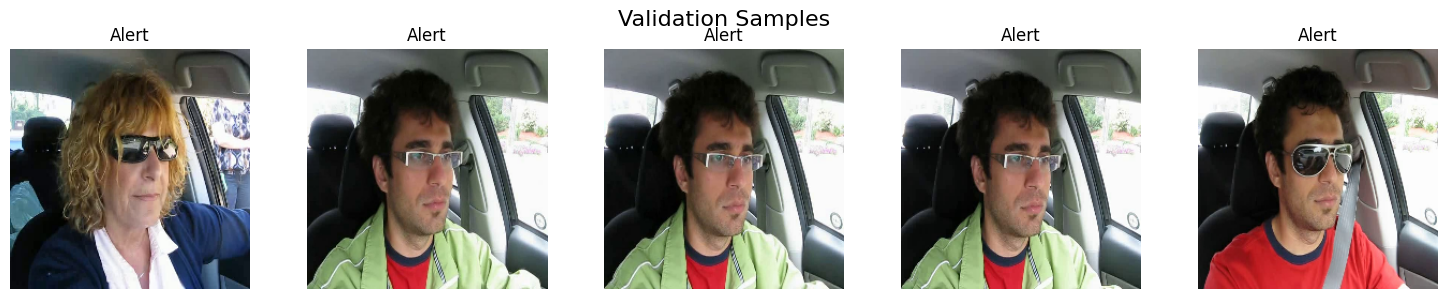

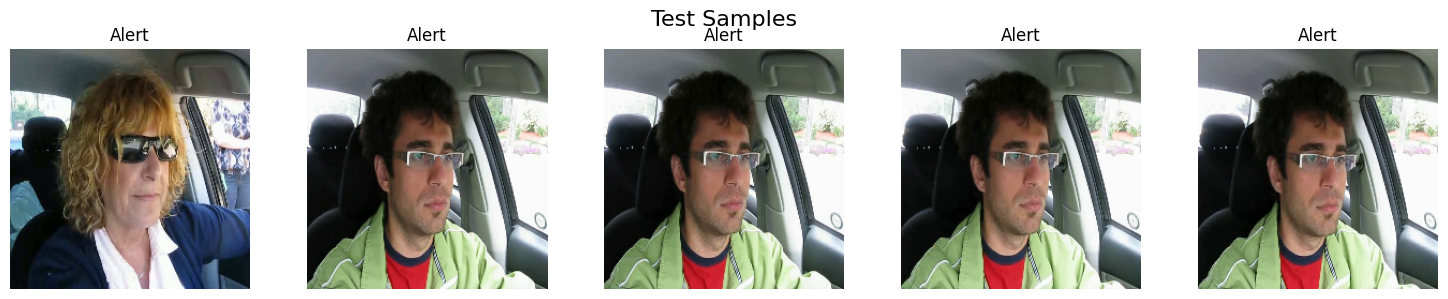

In [ ]:
def visualize_dataset_samples(dataset, title, num_samples=5):
    # Take a batch
    for images, labels in dataset.take(1):
        # Only use the number of samples we need
        images = images[:num_samples]
        labels = labels[:num_samples]

        plt.figure(figsize=(15, 3))
        plt.suptitle(title, fontsize=16)

        for i in range(num_samples):
            plt.subplot(1, num_samples, i + 1)

            # Convert from preprocessed back to displayable
            img = images[i].numpy()
            # For ResNet preprocessing: reverse the normalization approximately
            img = (img + 1) * 127.5
            img = np.clip(img, 0, 255).astype(np.uint8)

            plt.imshow(img)
            plt.title(f"{'Drowsy' if labels[i] else 'Alert'}")
            plt.axis('off')

        plt.tight_layout()
        plt.subplots_adjust(top=0.85)
        plt.show()

# Visualize samples from each dataset
visualize_dataset_samples(train_ds, "Training Samples")
visualize_dataset_samples(val_ds, "Validation Samples")
visualize_dataset_samples(test_ds, "Test Samples")

##Visualize Augmentations

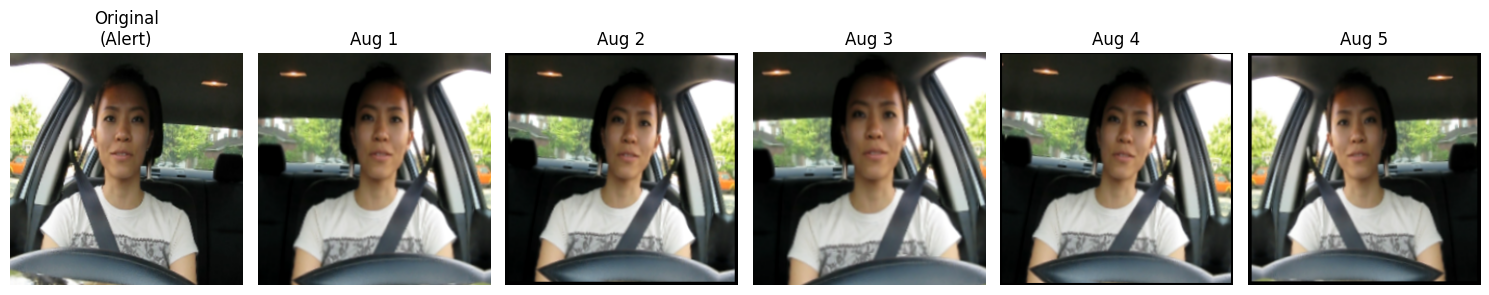

In [ ]:
def plot_augmentations(dataset, num_augmentations=5):
    data_augmentation = create_augmentation_model()

    # Get one image from dataset
    for images, labels in dataset.unbatch().take(1):
        # Convert preprocessed image back to displayable
        original_img = (images.numpy() + 1) * 127.5
        original_img = np.clip(original_img, 0, 255).astype(np.uint8)
        label = "Drowsy" if labels.numpy() == 1 else "Alert"

        plt.figure(figsize=(15, 4))
        plt.subplot(1, num_augmentations + 1, 1)
        plt.imshow(original_img)
        plt.title(f"Original\n({label})")
        plt.axis("off")

        # Generate multiple augmentations
        for i in range(num_augmentations):
            plt.subplot(1, num_augmentations + 1, i + 2)
            # Apply augmentation
            aug_img = data_augmentation(tf.expand_dims(tf.cast(original_img, tf.float32), 0), training=True)
            plt.imshow(aug_img[0].numpy().astype("uint8"))
            plt.title(f"Aug {i+1}")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

# Show sample augmentations
plot_augmentations(train_ds)


##Final Check

In [ ]:
print("\n===== Data Pipeline Summary =====")
print(f"Dataset location: {original_data_dir}")
print(f"Processed data location: {base_dir}")
print(f"Batch size: {batch_size}")

# Get number of batches in each dataset
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_batches = tf.data.experimental.cardinality(test_ds).numpy()

print(f"Training: {train_batches} batches")
print(f"Validation: {val_batches} batches")
print(f"Test: {test_batches} batches")

# Final message
print("\nData pipeline setup complete! The datasets (train_ds, val_ds, test_ds) are ready for model training.")


===== Data Pipeline Summary =====
Dataset location: /content/dataset
Processed data location: /content/Drowsiness_Detection_Demo/final_split
Batch size: 64
Training: 133 batches
Validation: 29 batches
Test: 29 batches

Data pipeline setup complete! The datasets (train_ds, val_ds, test_ds) are ready for model training.


##Save and Load Datasets

In [ ]:
def save_tf_datasets(train_ds, val_ds, test_ds, base_dir):
    """
    Save the TensorFlow datasets to disk for faster loading in future sessions
    """
    # Create directory for saved datasets
    save_dir = os.path.join(base_dir, 'saved_datasets')
    os.makedirs(save_dir, exist_ok=True)

    print("Saving datasets to disk...")

    # Save datasets using tf.data.experimental.save
    tf.data.experimental.save(train_ds, os.path.join(save_dir, 'train_ds'))
    tf.data.experimental.save(val_ds, os.path.join(save_dir, 'val_ds'))
    tf.data.experimental.save(test_ds, os.path.join(save_dir, 'test_ds'))

    print("Datasets saved successfully")
save_tf_datasets(train_ds, val_ds, test_ds, base_dir)

Instructions for updating:
Use `tf.data.Dataset.save(...)` instead.


Saving datasets to disk...
Datasets saved successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Copy tf datasets from drive

In [ ]:
os.makedirs("/content/Drowsiness_Detection", exist_ok=True) # Use makedirs instead of makedir
!cp -r /content/drive/MyDrive/tf_datasets/saved_datasets /content/Drowsiness_Detection/

##Load tf datasets

In [ ]:
import tensorflow as tf

load_dir = "/content/Drowsiness_Detection/saved_datasets"

train_ds = tf.data.Dataset.load(f"{load_dir}/train_ds")
val_ds = tf.data.Dataset.load(f"{load_dir}/val_ds")
test_ds = tf.data.Dataset.load(f"{load_dir}/test_ds")

print("Datasets loaded successfully!")


Datasets loaded successfully!


##Visualise Loaded Datasets

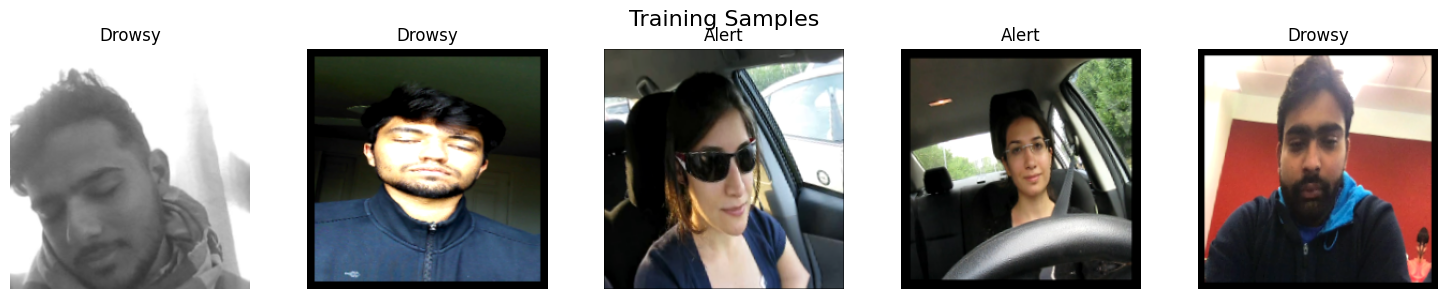

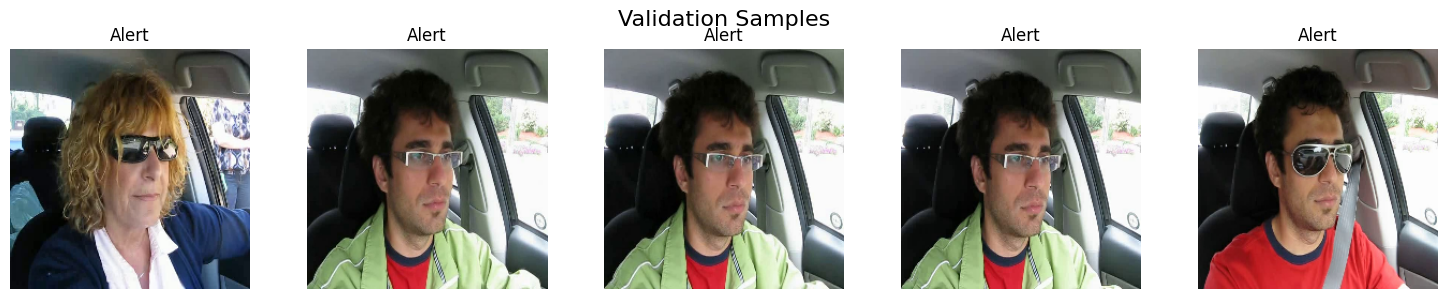

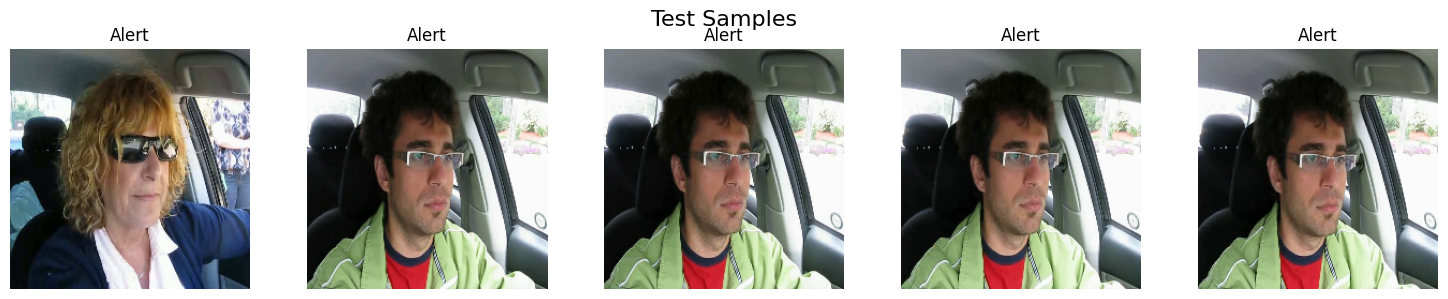

In [ ]:
def visualize_dataset_samples(dataset, title, num_samples=5):
    # Take a batch
    for images, labels in dataset.take(1):
        # Only use the number of samples we need
        images = images[:num_samples]
        labels = labels[:num_samples]

        plt.figure(figsize=(15, 3))
        plt.suptitle(title, fontsize=16)

        for i in range(num_samples):
            plt.subplot(1, num_samples, i + 1)

            # Convert from preprocessed back to displayable
            img = images[i].numpy()
            # For ResNet preprocessing: reverse the normalization approximately
            img = (img + 1) * 127.5
            img = np.clip(img, 0, 255).astype(np.uint8)

            plt.imshow(img)
            plt.title(f"{'Drowsy' if labels[i] else 'Alert'}")
            plt.axis('off')

        plt.tight_layout()
        plt.subplots_adjust(top=0.85)
        plt.show()

# Visualize samples from each dataset
visualize_dataset_samples(train_ds, "Training Samples")
visualize_dataset_samples(val_ds, "Validation Samples")
visualize_dataset_samples(test_ds, "Test Samples")

##Build Model

In [ ]:
def build_resnet_model():
    # Create base model with proper name
    base_model = ResNet50V2(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
        name='resnet50v2_backbone'
    )

    # Initially freeze the base model
    base_model.trainable = False

    # Create model without data augmentation in the model itself
    # (since it's already applied in the dataset pipeline)
    inputs = tf.keras.Input(shape=(224, 224, 3))

    # Note: Remove augmentation and preprocessing here since they're in the dataset pipeline
    x = base_model(inputs)  # Directly feed inputs to base model

    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu', kernel_regularizer=regularizers.l1_l2(0.005))(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    # Compile with metrics
    model.compile(
        optimizer=Adamax(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    return model

# Create the model
model = build_resnet_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50v2_backbone (Functional)     │ (None, 7, 7, 2048)          │      23,564,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,106,881 (91.96 MB)

 Trainable params: 541,569 (2.07 MB)

 Non-trainable params: 23,565,312 (89.89 MB)

##Define learning rate scheduler

In [ ]:
def lr_scheduler(epoch):
    initial_lr = 1e-3
    decay_factor = 0.9
    return initial_lr * (decay_factor ** epoch)

##Initial training phase

In [ ]:
initial_epochs = 20
history = model.fit(
    train_ds,
    epochs=initial_epochs,
    validation_data=val_ds,
    callbacks=[
        EarlyStopping(patience=5, monitor='val_loss'),
        ModelCheckpoint('best_model.keras', save_best_only=True),
        ReduceLROnPlateau(factor=0.2, patience=2),
        CSVLogger('training_log.csv')
    ],
    verbose=1
)

Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 72s 403ms/step - accuracy: 0.7026 - loss: 8.4646 - precision: 0.6888 - recall: 0.7407 - val_accuracy: 0.8116 - val_loss: 4.8900 - val_precision: 0.8353 - val_recall: 0.7752 - learning_rate: 0.0010
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 57s 295ms/step - accuracy: 0.7971 - loss: 4.3097 - precision: 0.7973 - recall: 0.7937 - val_accuracy: 0.8260 - val_loss: 2.9704 - val_precision: 0.8364 - val_recall: 0.8095 - learning_rate: 0.0010
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 39s 296ms/step - accuracy: 0.8181 - loss: 2.6748 - precision: 0.8240 - recall: 0.8062 - val_accuracy: 0.8254 - val_loss: 1.9875 - val_precision: 0.8250 - val_recall: 0.8250 - learning_rate: 0.0010
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 39s 296ms/step - accuracy: 0.8314 - loss: 1.8013 - precision: 0.8314 - recall: 0.8290 - val_accuracy: 0.8221 - val_loss: 1.4181 - val_precision: 0.8564 - val_recall: 0.7730 - learning_rate: 0.0010
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 39s 296ms/st

##Fine-tuning phase

In [ ]:
# Get the base model and unfreeze it
base_model = model.get_layer('resnet50v2_backbone')
base_model.trainable = True

# Freeze non-convolutional layers and unfreeze only the last few blocks
for layer in base_model.layers:
    if not isinstance(layer, layers.Conv2D):
        layer.trainable = False

# Unfreeze the last 4 blocks for fine-tuning
for i, layer in enumerate(base_model.layers):
    if i >= len(base_model.layers) - 40:  # Approximately last 4 blocks
        layer.trainable = True

# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=Adamax(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# Continue training
history_fine = model.fit(
    train_ds,
    epochs=30,
    initial_epoch=history.epoch[-1],
    validation_data=val_ds,
    callbacks=[
        EarlyStopping(patience=5, monitor='val_loss'),
        ModelCheckpoint('best_model.keras', save_best_only=True),
        ReduceLROnPlateau(factor=0.2, patience=2),
        CSVLogger('training_log.csv', append=True)  # Append to existing log
    ]
)


Epoch 20/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 125s 606ms/step - accuracy: 0.7943 - loss: 0.6021 - precision: 0.7963 - recall: 0.7881 - val_accuracy: 0.8613 - val_loss: 0.4687 - val_precision: 0.8928 - val_recall: 0.8206 - learning_rate: 1.0000e-05
Epoch 21/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 65s 486ms/step - accuracy: 0.9119 - loss: 0.3706 - precision: 0.9172 - recall: 0.9040 - val_accuracy: 0.8586 - val_loss: 0.4608 - val_precision: 0.9069 - val_recall: 0.7984 - learning_rate: 1.0000e-05
Epoch 22/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 63s 476ms/step - accuracy: 0.9409 - loss: 0.3202 - precision: 0.9454 - recall: 0.9348 - val_accuracy: 0.8669 - val_loss: 0.4574 - val_precision: 0.9211 - val_recall: 0.8018 - learning_rate: 1.0000e-05
Epoch 23/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 63s 476ms/step - accuracy: 0.9583 - loss: 0.2823 - precision: 0.9632 - recall: 0.9524 - val_accuracy: 0.8735 - val_loss: 0.4441 - val_precision: 0.9223 - val_recall: 0.8151 - learning_rate: 1.0000e-05
Epoch 24/30
133/133 ━━━━━━━━━━━

##Plot Training History

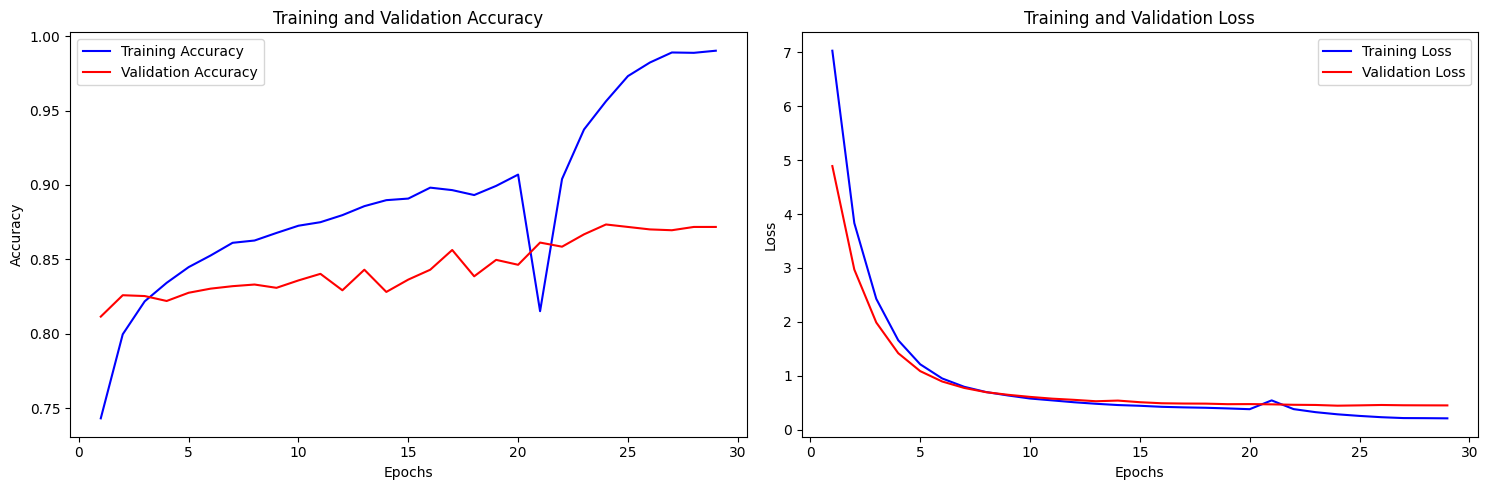

In [ ]:
# Plot training history
def plot_training_history(history, fine_tune_history=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Combine histories if fine-tuning was done
    if fine_tune_history:
        acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
        val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
        loss = history.history['loss'] + fine_tune_history.history['loss']
        val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']
        epochs = range(1, len(acc) + 1)
    else:
        acc = history.history['accuracy']
        val_acc = history.history['val_accuracy']
        loss = history.history['loss']
        val_loss = history.history['val_loss']
        epochs = range(1, len(acc) + 1)

    # Accuracy plot
    ax1.plot(epochs, acc, 'b-', label='Training Accuracy')
    ax1.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    ax1.set_title('Training and Validation Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Loss plot
    ax2.plot(epochs, loss, 'b-', label='Training Loss')
    ax2.plot(epochs, val_loss, 'r-', label='Validation Loss')
    ax2.set_title('Training and Validation Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history=history, fine_tune_history=history_fine)

##Confusion Matrix

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step


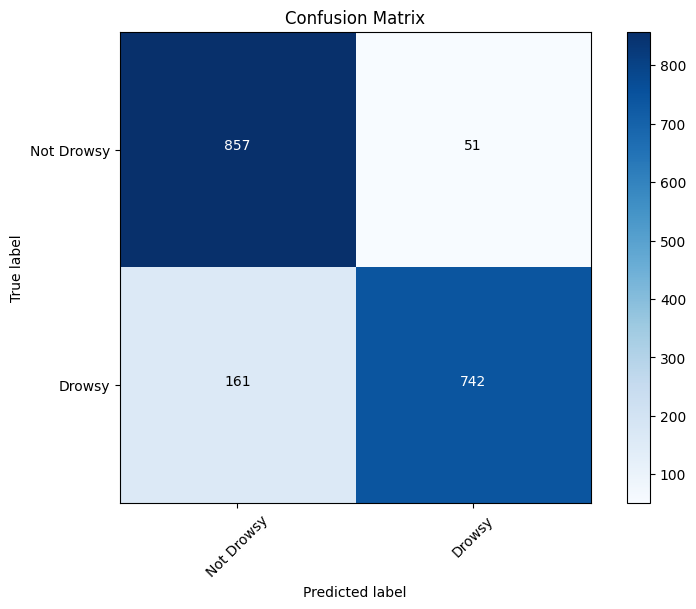

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Generate predictions on test set
y_pred_prob = model.predict(test_ds)
y_pred = (y_pred_prob > 0.5).astype(int)

# Extract true labels from test dataset
y_true = np.concatenate([y for _, y in test_ds], axis=0)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
classes = ['Not Drowsy', 'Drowsy']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

#Evaluation

Extracting true labels and generating predictions...


Evaluating batches: 100%|██████████| 29/29 [00:40<00:00,  1.41s/it]



--- Model Evaluation Results ---

Computing standard metrics...
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 202ms/step - accuracy: 0.9172 - loss: 0.3530 - precision: 0.4456 - recall: 0.4179

Accuracy: 0.8829
Precision: 0.9357
Recall: 0.8217
F1 Score: 0.8750

Generating confusion matrix...


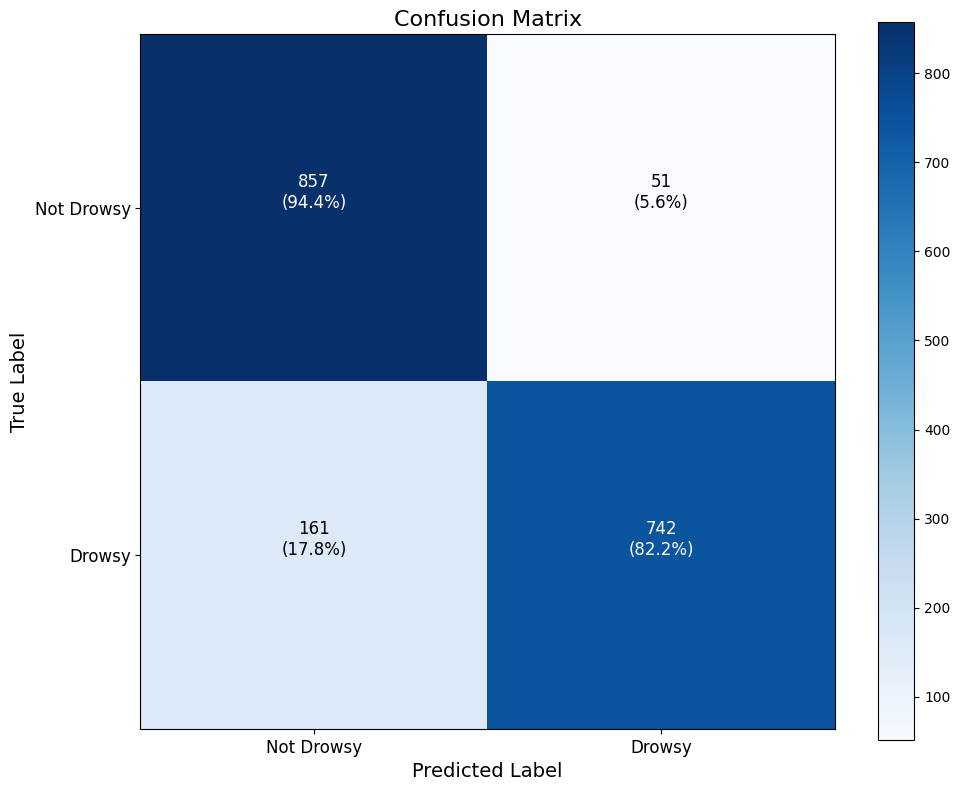

True Positives: 742
False Positives: 51
True Negatives: 857
False Negatives: 161
Specificity: 0.9438

Generating ROC curve...


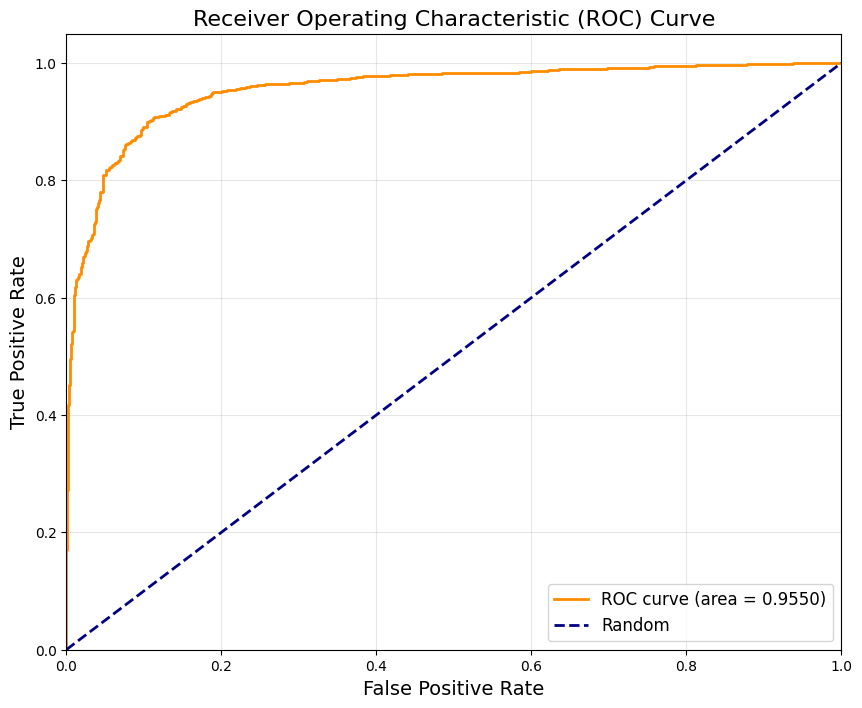

ROC AUC: 0.9550

Generating Precision-Recall curve...


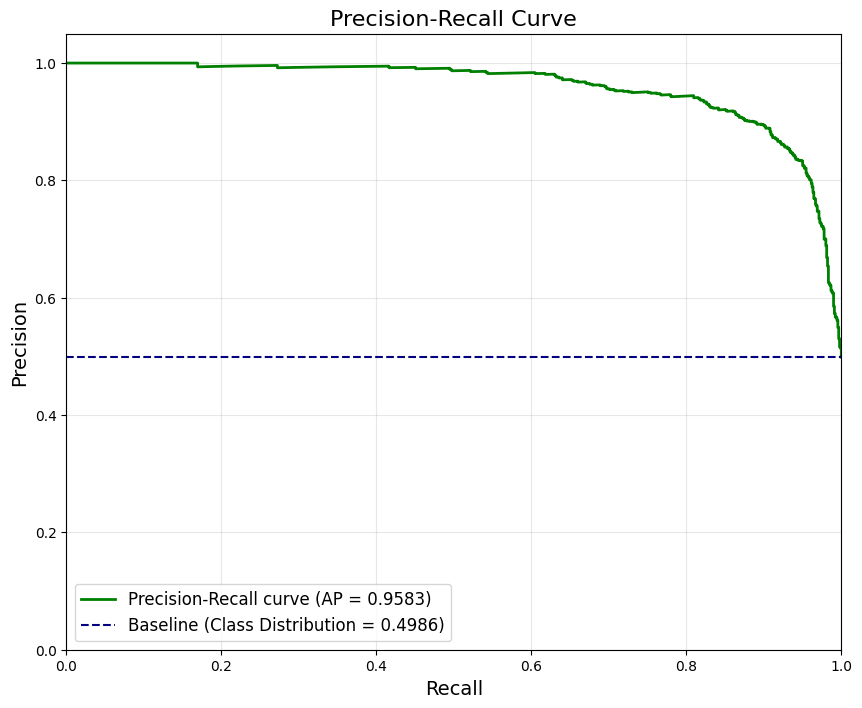

Average Precision (AP): 0.9583

Detailed Classification Report:
              precision  recall  f1-score    support
Not Drowsy       0.8418  0.9438    0.8899   908.0000
Drowsy           0.9357  0.8217    0.8750   903.0000
accuracy         0.8829  0.8829    0.8829     0.8829
macro avg        0.8888  0.8828    0.8825  1811.0000
weighted avg     0.8886  0.8829    0.8825  1811.0000

Finding optimal threshold (maximizing F1 score)...


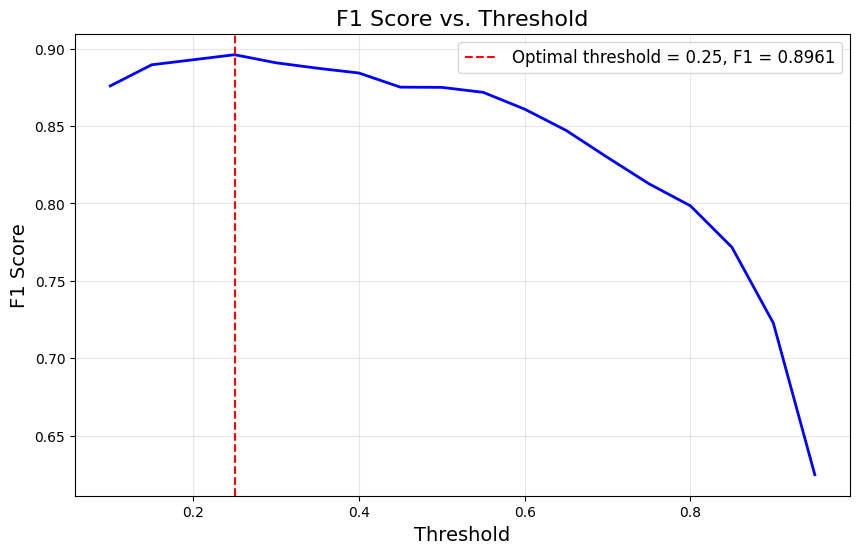

Optimal threshold: 0.25
F1 score at optimal threshold: 0.8961

Measuring inference speed...
Average inference time per image: 5.57 ms
Theoretical max throughput: 179.65 images/second

--- Summary of Key Metrics ---
loss: 0.4254
accuracy: 0.8829
precision: 0.9357
recall: 0.8217
f1_score: 0.8750
specificity: 0.9438
roc_auc: 0.9550
average_precision: 0.9583
optimal_threshold: 0.2500
optimal_f1_score: 0.8961
inference_time_per_image_ms: 5.5663
inference_fps: 179.6538


{'loss': 0.4254041910171509,
 'accuracy': 0.8829376101493835,
 'precision': 0.935687243938446,
 'recall': 0.8217054009437561,
 'f1_score': 0.8749999272245038,
 'specificity': np.float64(0.9438325991189427),
 'roc_auc': np.float64(0.9549909503807671),
 'average_precision': np.float64(0.9582754467837942),
 'optimal_threshold': np.float64(0.25000000000000006),
 'optimal_f1_score': np.float64(0.8960967063636236),
 'inference_time_per_image_ms': 5.56626096367836,
 'inference_fps': 179.65381187215638}

In [ ]:
def evaluate_drowsiness_model(model, test_ds, class_names=['Not Drowsy', 'Drowsy'], threshold=0.5):
    """
    Comprehensively evaluate a drowsiness detection model with multiple metrics and visualizations.

    Parameters:
    -----------
    model : tf.keras.Model
        The trained model to evaluate
    test_ds : tf.data.Dataset
        Test dataset to evaluate on
    class_names : list
        Names of the classes (default: ['Not Drowsy', 'Drowsy'])
    threshold : float
        Decision threshold for binary classification (default: 0.5)

    Returns:
    --------
    dict
        Dictionary containing all evaluation metrics
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
    import pandas as pd
    import time
    from tqdm import tqdm

    # Extract true labels and generate predictions
    print("Extracting true labels and generating predictions...")
    y_true = []
    y_pred_prob = []

    # Use tqdm for a progress bar
    total_batches = tf.data.experimental.cardinality(test_ds).numpy()

    for x, y in tqdm(test_ds, total=total_batches, desc="Evaluating batches"):
        # Get predictions for this batch
        batch_pred = model.predict(x, verbose=0)
        y_pred_prob.extend(batch_pred.flatten())
        y_true.extend(y.numpy().flatten())

    # Convert to numpy arrays
    y_true = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)

    # Convert probabilities to binary predictions using threshold
    y_pred = (y_pred_prob >= threshold).astype(int)

    # 1. Basic Metrics
    print("\n--- Model Evaluation Results ---")

    # Standard metrics from model.evaluate
    print("\nComputing standard metrics...")
    test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_ds, verbose=1)

    # Create a dictionary to store all metrics
    metrics = {
        'loss': test_loss,
        'accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall
    }

    # Compute F1 Score
    f1_score = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-7)
    metrics['f1_score'] = f1_score

    print(f"\nAccuracy: {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"F1 Score: {f1_score:.4f}")

    # 2. Confusion Matrix
    print("\nGenerating confusion matrix...")
    cm = confusion_matrix(y_true, y_pred)

    # Calculate additional metrics from confusion matrix
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    metrics['specificity'] = specificity

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix', fontsize=16)
    plt.colorbar()

    # Normalize confusion matrix for percentages
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Add text annotations with both raw numbers and percentages
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f'{cm[i, j]}\n({cm_norm[i, j]:.1%})',
                    horizontalalignment="center", fontsize=12,
                    color="white" if cm[i, j] > thresh else "black")

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, fontsize=12)
    plt.yticks(tick_marks, class_names, fontsize=12)
    plt.tight_layout()
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.grid(False)
    plt.show()

    # Calculate and print derived metrics
    print(f"True Positives: {tp}")
    print(f"False Positives: {fp}")
    print(f"True Negatives: {tn}")
    print(f"False Negatives: {fn}")
    print(f"Specificity: {specificity:.4f}")

    # 3. ROC Curve
    print("\nGenerating ROC curve...")
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    metrics['roc_auc'] = roc_auc

    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"ROC AUC: {roc_auc:.4f}")

    # 4. Precision-Recall Curve
    print("\nGenerating Precision-Recall curve...")
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_prob)
    avg_precision = average_precision_score(y_true, y_pred_prob)
    metrics['average_precision'] = avg_precision

    plt.figure(figsize=(10, 8))
    plt.plot(recall, precision, color='green', lw=2,
             label=f'Precision-Recall curve (AP = {avg_precision:.4f})')
    plt.axhline(y=sum(y_true) / len(y_true), color='navy', linestyle='--',
                label=f'Baseline (Class Distribution = {sum(y_true) / len(y_true):.4f})')
    plt.xlabel('Recall', fontsize=14)
    plt.ylabel('Precision', fontsize=14)
    plt.ylim([0.0, 1.05])
    plt.xlim([0.0, 1.0])
    plt.title('Precision-Recall Curve', fontsize=16)
    plt.legend(loc="lower left", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Average Precision (AP): {avg_precision:.4f}")

    # 5. Classification Report
    print("\nDetailed Classification Report:")
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    print(report_df.round(4))

    # 6. Finding optimal threshold
    print("\nFinding optimal threshold (maximizing F1 score)...")
    f1_scores = []
    thresholds_list = np.arange(0.1, 1.0, 0.05)

    for t in thresholds_list:
        temp_pred = (y_pred_prob >= t).astype(int)
        precision = sum(np.logical_and(temp_pred == 1, y_true == 1)) / (sum(temp_pred == 1) + 1e-7)
        recall = sum(np.logical_and(temp_pred == 1, y_true == 1)) / (sum(y_true == 1) + 1e-7)
        f1 = 2 * precision * recall / (precision + recall + 1e-7)
        f1_scores.append(f1)

    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds_list[optimal_idx]
    metrics['optimal_threshold'] = optimal_threshold
    metrics['optimal_f1_score'] = f1_scores[optimal_idx]

    plt.figure(figsize=(10, 6))
    plt.plot(thresholds_list, f1_scores, 'b-', linewidth=2)
    plt.axvline(x=optimal_threshold, color='r', linestyle='--',
                label=f'Optimal threshold = {optimal_threshold:.2f}, F1 = {f1_scores[optimal_idx]:.4f}')
    plt.xlabel('Threshold', fontsize=14)
    plt.ylabel('F1 Score', fontsize=14)
    plt.title('F1 Score vs. Threshold', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Optimal threshold: {optimal_threshold:.2f}")
    print(f"F1 score at optimal threshold: {f1_scores[optimal_idx]:.4f}")

    # 7. Inference Speed
    print("\nMeasuring inference speed...")
    # Take a small subset of the test data for timing
    time_dataset = test_ds.take(5)  # Take 5 batches

    # Measure inference time
    start_time = time.time()
    for x, _ in time_dataset:
        _ = model.predict(x, verbose=0)
    end_time = time.time()

    # Calculate average inference time per batch and per image
    total_time = end_time - start_time
    avg_time_per_batch = total_time / 5  # 5 batches
    batch_size = x.shape[0]
    avg_time_per_image = avg_time_per_batch / batch_size

    metrics['inference_time_per_image_ms'] = avg_time_per_image * 1000  # Convert to ms
    metrics['inference_fps'] = 1.0 / avg_time_per_image  # Frames per second

    print(f"Average inference time per image: {avg_time_per_image*1000:.2f} ms")
    print(f"Theoretical max throughput: {1.0/avg_time_per_image:.2f} images/second")

    # 8. Output summary of all metrics
    print("\n--- Summary of Key Metrics ---")
    for metric_name, metric_value in metrics.items():
        if isinstance(metric_value, float):
            print(f"{metric_name}: {metric_value:.4f}")
        else:
            print(f"{metric_name}: {metric_value}")

    return metrics
evaluate_drowsiness_model(model, test_ds, class_names=['Not Drowsy', 'Drowsy'], threshold=0.5)